# Sree Ram Roshan A S - 24BAD113

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Create validation set
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1350s 8us/step
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


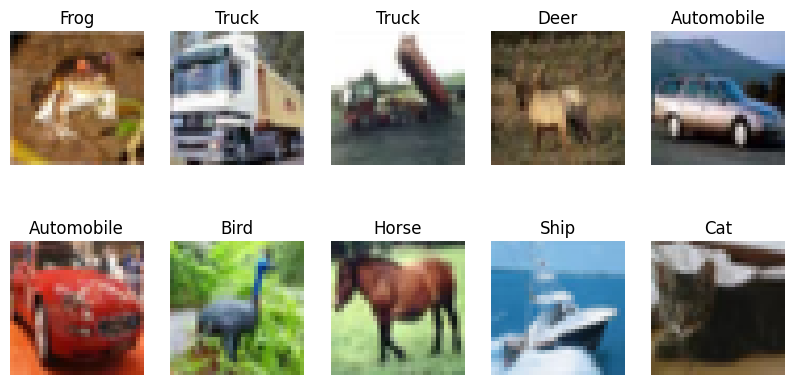

In [2]:
classes = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis("off")

plt.show()

# CNN Implementation

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',
                 input_shape=(32,32,3)))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_val,y_val)
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 73s 51ms/step - accuracy: 0.4947 - loss: 1.4125 - val_accuracy: 0.5908 - val_loss: 1.1640
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.6282 - loss: 1.0673 - val_accuracy: 0.6634 - val_loss: 0.9880
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.6771 - loss: 0.9256 - val_accuracy: 0.6844 - val_loss: 0.9264
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 47ms/step - accuracy: 0.7120 - loss: 0.8244 - val_accuracy: 0.7082 - val_loss: 0.8603
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.7418 - loss: 0.7418 - val_accuracy: 0.7060 - val_loss: 0.8490
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.7690 - loss: 0.6635 - val_accuracy: 0.7032 - val_loss: 0.8945
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 45ms/step - accuracy: 0.7906 - loss: 0.5968 - val_accuracy: 0.7152 - val_loss: 0.8626
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.8149 -

In [6]:
test_loss,test_acc = model.evaluate(x_test,y_test)

print("Testing Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6932 - loss: 1.0459
Testing Accuracy: 0.6931999921798706


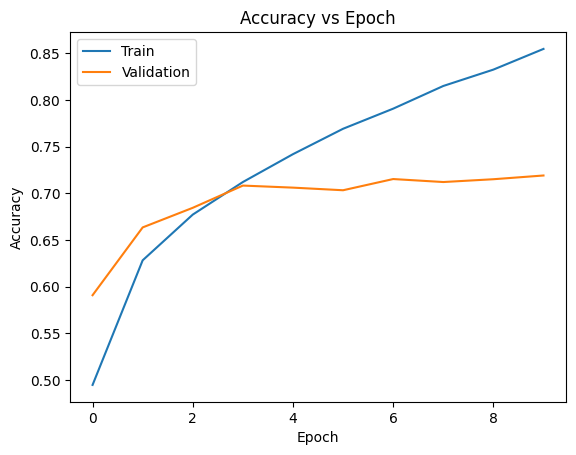

In [7]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

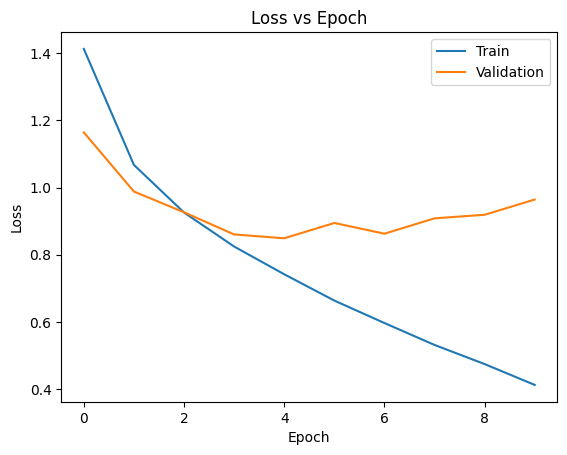

In [8]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step


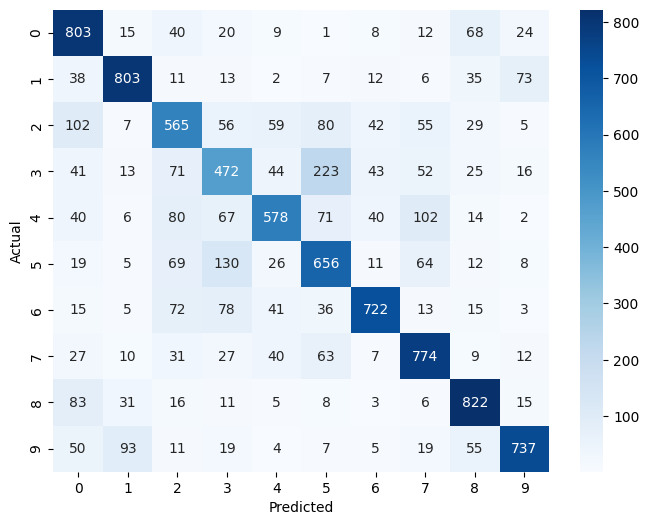

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

pred = model.predict(x_test)
pred = np.argmax(pred,axis=1)

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

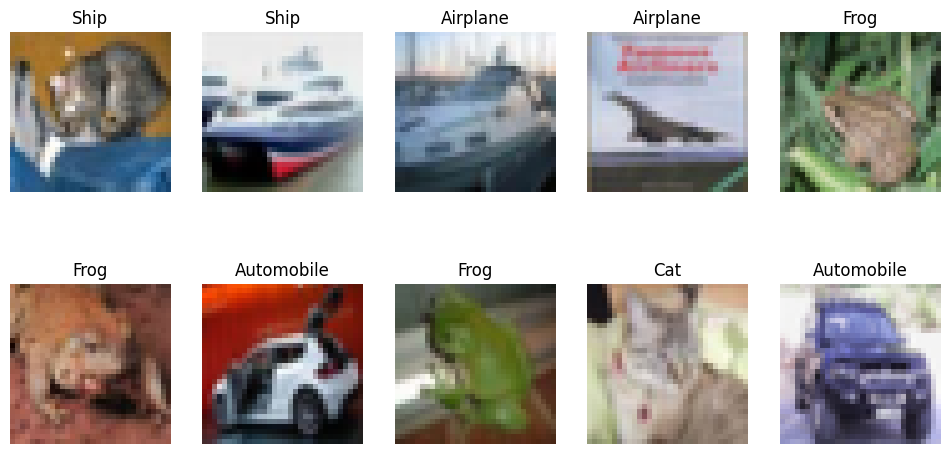

In [10]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title(classes[pred[i]])
    plt.axis("off")

plt.show()

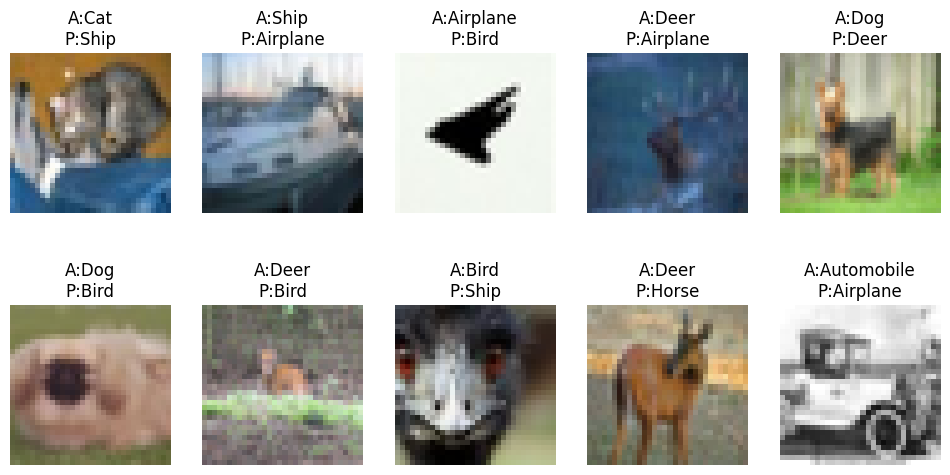

In [11]:
mis = np.where(pred != y_test.flatten())[0]

plt.figure(figsize=(12,6))

for i in range(10):
    idx = mis[i]
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx])
    plt.title(f"A:{classes[y_test[idx][0]]}\nP:{classes[pred[idx]]}")
    plt.axis("off")

plt.show()